- Рубежная работа №1

- Выполнил: Антипин Григорий Викторович P3332

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import CubicSpline
from scipy.fft import rfft, rfftfreq
from statsmodels.tsa.stattools import acf

In [64]:
csv_path = r"C:\Users\antip\OneDrive\Desktop\Школа\Биометрия\2_f_1.csv"

df = None
try:
    df = pd.read_csv(csv_path)
except Exception:
    df = pd.read_csv(csv_path, header=None)

rr_series = None
for col in df.columns:
    col_vals = pd.to_numeric(df[col], errors="coerce")
    if col_vals.notna().mean() > 0.9:
        rr_series = col_vals.dropna().astype(float)
        break

rr_ms = rr_series[(rr_series > 300) & (rr_series < 2000)].reset_index(drop=True)
n = len(rr_ms)

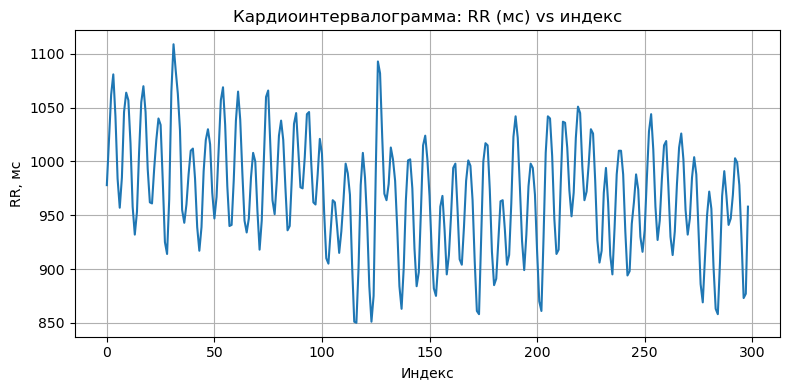

In [65]:
#1. Построить кардиоинтервалограмму (зависимость длины RR-интервала от его индекса).
plt.figure()
plt.plot(np.arange(n), rr_ms.values, linewidth=1.5)
plt.title("Кардиоинтервалограмма: RR (мс) vs индекс")
plt.xlabel("Индекс")
plt.ylabel("RR, мс")
plt.tight_layout()
plt.show()


In [62]:
#2. Рассчитать следующие показатели: частоту сердечных сокращений, среднее значение, 
#стандартное отклонение (SDNN),  коэффициент вариации (CV) и среднеквадратическую разностную характеристику RMSSD.
#Проанализировать полученные результаты.
M = rr_ms.mean()
SDNN = rr_ms.std(ddof=1)
CV = SDNN / M * 100.0
diffs = np.diff(rr_ms.values)
RMSSD = np.sqrt(np.mean(diffs**2))
HR_mean = 60000.0 / M

metrics = pd.DataFrame({
    "Показатель": ["средняя частота сердечных сокращений (уд/мин)", "средняя пауза между ударами сердца (мс)", "стандартное отклонение (мс)", "коэффициент вариации (%)", "среднеквадратическая разностная характеристика (мс)"],
    "Значение": [HR_mean, M, SDNN, CV, RMSSD]
})
display(metrics)

,Показатель,Значение
0,средняя частота сердечных сокращений (уд/мин),61.832219
1,средняя пауза между ударами сердца (мс),970.367893
2,стандартное отклонение (мс),52.431276
3,коэффициент вариации (%),5.403237
4,среднеквадратическая разностная характеристика...,37.722761


- Средняя частота сердечных сокращений — около 62 уд/мин, что считается нормой и говорит о спокойном состоянии организма.

- Средний RR-интервал (970 мс) показывает равномерный ритм без выраженных отклонений.

- Значения SDNN (52 мс) и RMSSD (38 мс) говорят о достаточной вариабельности сердечного ритма, то есть сердце хорошо приспосабливается к изменениям состояния.

- Коэффициент вариации (5.4%) — в пределах нормы, ритм стабилен и сбалансирован.

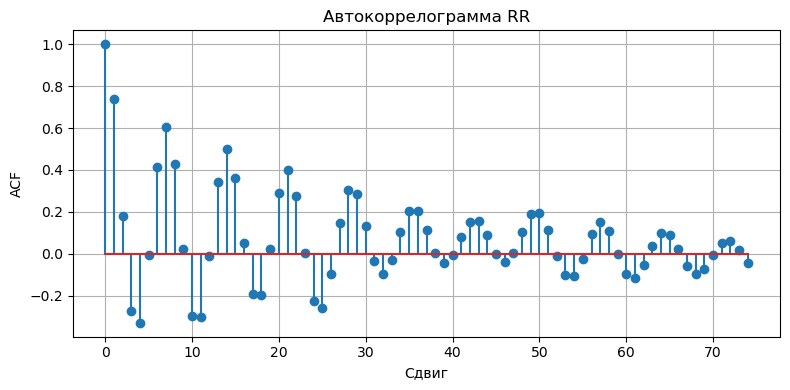

In [68]:
#3. Построить график автокоррелограммы. 
# Для расчета коэффициента корреляции можно воспользоваться библиотекой statsmodels.
nshifts = min(128, max(10, n//4))
acf_vals = acf(rr_ms.values, nlags=nshifts, fft=True)
shifts = np.arange(len(acf_vals))

plt.figure()
plt.stem(shifts, acf_vals)
plt.title("Автокоррелограмма RR")
plt.xlabel("Сдвиг")
plt.ylabel("ACF")
plt.tight_layout()
plt.show()


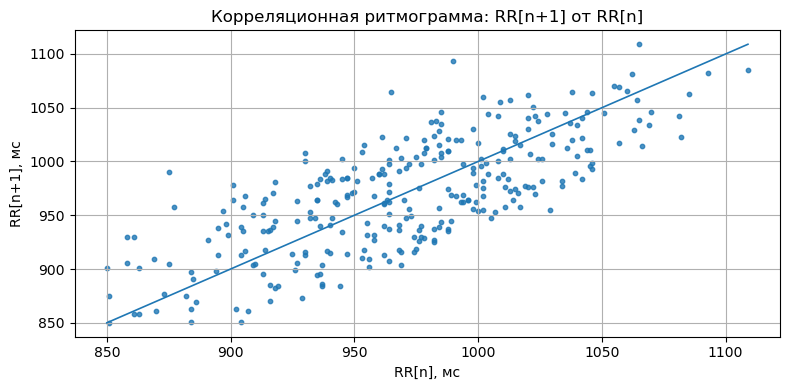

In [54]:
#4. Построить корреляционную ритмограмму, т.е. график зависимости следующего RR-интервала от предыдущего
#Проанализировать полученные результаты на наличие аритмии.

x_prev = rr_ms.values[:-1]
y_next = rr_ms.values[1:]

plt.figure()
plt.scatter(x_prev, y_next, s=10, alpha=0.8)
mn = float(min(x_prev.min(), y_next.min()))
mx = float(max(x_prev.max(), y_next.max()))
plt.plot([mn, mx], [mn, mx], linewidth=1.2)
plt.title("Корреляционная ритмограмма: RR[n+1] от RR[n]")
plt.xlabel("RR[n], мс")
plt.ylabel("RR[n+1], мс")
plt.tight_layout()
plt.show()


- По корреляционной ритмограмме видно, что последовательность RR-интервалов равномерна, точки плотно сгруппированы вдоль диагонали.

- Выраженных выбросов и кластеров нет. Это указывает на отсутствие аритмий и наличие нормального синусового ритма с умеренной физиологической вариабельностью.

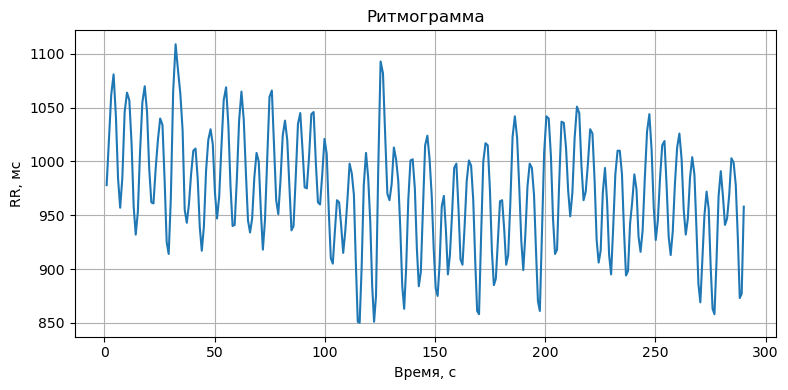

In [69]:
#5. Построить график ритмограммы (зависимость длительности RR-интервала от времени его появления).
t_sec = np.cumsum(rr_ms.values) / 1000.0

plt.figure()
plt.plot(t_sec, rr_ms.values, linewidth=1.5)
plt.title("Ритмограмма")
plt.xlabel("Время, с")
plt.ylabel("RR, мс")
plt.tight_layout()
plt.show()

Длина после интерполяции: 1157 (fs ≈ 4.0 Гц)


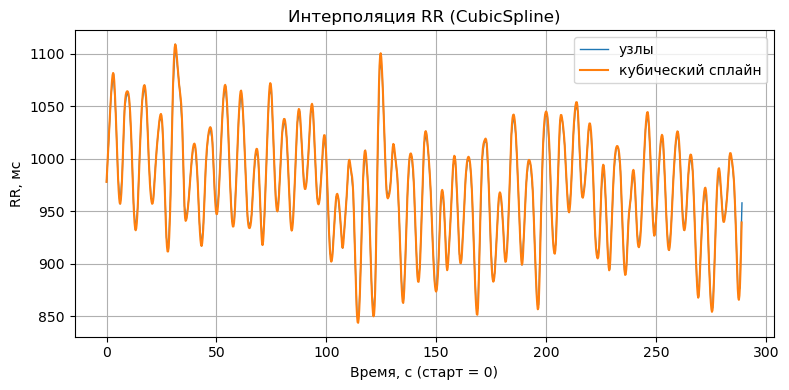

In [70]:
#6. Провести кубическую интерполяцию (модуль CubicSpline библиотеки scipy) и передискретизацию полученной кривой с постоянным шагом 250 мс.

dt = 0.25
t_uniform = np.arange(t_sec[0], t_sec[-1], dt)

t0 = t_uniform[0]
t_uniform_z = t_uniform - t0
t_sec_z = t_sec - t0

cs = CubicSpline(t_sec_z, rr_ms.values)
rr_interp = cs(t_uniform_z)

print(f"Длина после интерполяции: {len(rr_interp)} (fs ≈ {1/dt:.1f} Гц)")

plt.figure()
plt.plot(t_sec_z, rr_ms.values, linewidth=1.0, label="узлы")
plt.plot(t_uniform_z, rr_interp, linewidth=1.5, label="кубический сплайн")
plt.title("Интерполяция RR (CubicSpline)")
plt.xlabel("Время, с (старт = 0)")
plt.ylabel("RR, мс")
plt.legend()
plt.tight_layout()
plt.show()

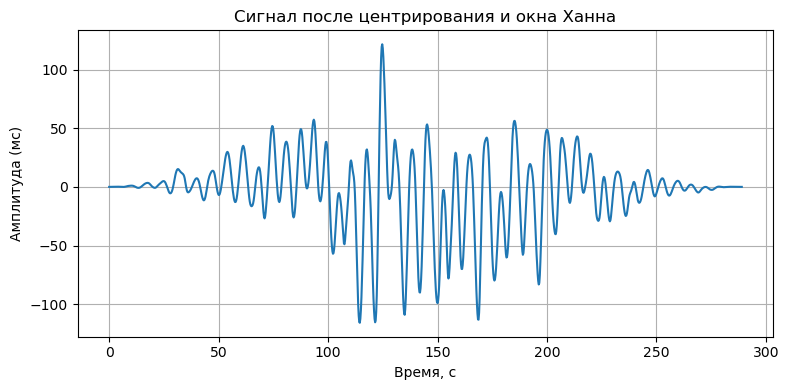

In [71]:
# 7. Провести оконное преобразование полученного сигнала, применив окно Ханна

fs = 1.0 / dt
x = rr_interp - np.mean(rr_interp)
window = np.hanning(len(x))
xw = x * window

plt.figure()
plt.plot(t_uniform_z, xw, linewidth=1.5)
plt.title("Сигнал после центрирования и окна Ханна")
plt.xlabel("Время, с")
plt.ylabel("Амплитуда (мс)")
plt.tight_layout()
plt.show()


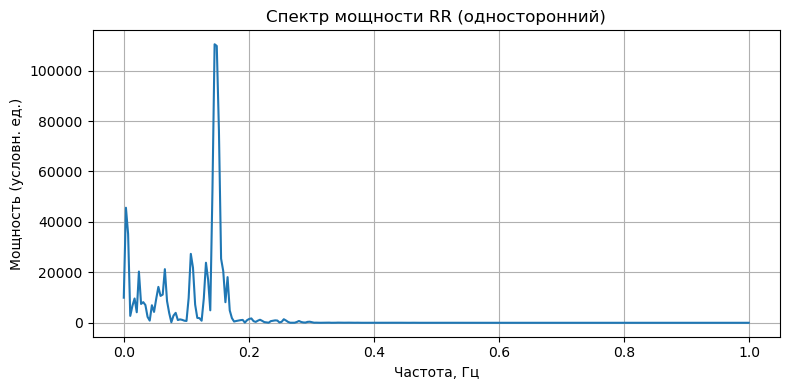

In [72]:
#8. Выполнить быстрое преобразование Фурье для перехода в частотную область, воспользовавшись модулем fft библиотеки scipy.

N = len(xw)
X = rfft(xw)
freqs = rfftfreq(N, d=dt)

U = (window**2).sum()
Pxx = (np.abs(X)**2) / (U * fs)
if len(Pxx) > 1:
    Pxx[1:-1] *= 2.0

mask = freqs <= 1.0
plt.figure()
plt.plot(freqs[mask], Pxx[mask], linewidth=1.5)
plt.title("Спектр мощности RR (односторонний)")
plt.xlabel("Частота, Гц")
plt.ylabel("Мощность (условн. ед.)")
plt.tight_layout()
plt.show()

In [59]:
#9. Рассчитать мощности спектра в HF, LF и VLF диапазонах, а также индекс вагосимпатического взаимодействия: ИВВ = LF/НF.

def band_power(freqs, Pxx, fmin, fmax):
    m = (freqs >= fmin) & (freqs < fmax)
    if not np.any(m):
        return 0.0
    return np.trapezoid(Pxx[m], freqs[m])

VLF = band_power(freqs, Pxx, 0.015, 0.04)
LF  = band_power(freqs, Pxx, 0.04, 0.15)
HF  = band_power(freqs, Pxx, 0.15, 0.40)
TP  = VLF + LF + HF
LF_HF = (LF / HF) if HF > 0 else np.inf

bands = pd.DataFrame({
    "Диапазон": ["VLF (0.015–0.04)", "LF (0.04–0.15)", "HF (0.15–0.40)", "Total (VLF+LF+HF)"],
    "Мощность": [VLF, LF, HF, TP],
    "Доля от TP, %": [
        100*VLF/TP if TP>0 else np.nan,
        100*LF/TP if TP>0 else np.nan,
        100*HF/TP if TP>0 else np.nan,
        100.0
    ]
})
display(bands.round(4))
print(f"Индекс LF/HF = {LF_HF:.3f}")

,Диапазон,Мощность,"Доля от TP, %"
0,VLF (0.015–0.04),183.9041,8.3082
1,LF (0.04–0.15),1545.7271,69.8314
2,HF (0.15–0.40),483.8818,21.8604
3,Total (VLF+LF+HF),2213.5130,100.0000


Индекс LF/HF = 3.194


In [60]:
if np.isfinite(LF_HF):
    if LF_HF < 0.5:
        tone = "ваготония"
    elif LF_HF <= 2.0:
        tone = "нормотония"
    else:
        tone = "симпатикотония"

print("Тип регуляции по LF/HF:", tone)

Тип регуляции по LF/HF: симпатикотония
